In [2]:
# ============================================================
# CELL 0 — IMPORTS & ENVIRONMENT SETUP
# ============================================================
# Standard data-manipulation and numerical libraries
# pandas  : DataFrames for loading, cleaning, and merging datasets
# numpy   : Numerical operations and log transformations

# Visualization libraries
# matplotlib / seaborn : Static 9-panel EDA figure and heatmap
# plotly               : Interactive charts used in the Panel dashboard

# Machine-learning utilities (scikit-learn)
# LinearRegression         : Baseline parametric model
# RandomForestRegressor    : Non-linear ensemble model
# cross_val_score / LOO    : Leave-One-Out CV (appropriate for small datasets)
# r2_score / MSE           : Evaluation metrics
# StandardScaler           : Feature standardization before LR

# Dashboard framework
# panel (pn) : Builds the interactive multi-tab web dashboard
# pnw        : Panel widget helpers (DataFrame widget used in Tab 2)
# pn.extension : Registers the Plotly pane and sets default sizing mode

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

import panel as pn
import panel.widgets as pnw

pn.extension('plotly', sizing_mode='stretch_width')

In [3]:
# ============================================================
# CELL 1 — STEP 1: DATA COLLECTION
# ============================================================
# Loads the three raw CSV files that power the entire project:
#
#   FILE 1 — RS_Session.csv   : Annual UPI totals from NPCI
#             Columns: Year (FY label), Volume (Million), Value (Rs. crore)
#
#   FILE 2 — UPI_Transactions.csv : Monthly P2P & P2M breakdowns
#             Columns: Month, Total_Volume, Total_Value,
#                      P2P_Volume, P2P_Value, P2M_Volume, P2M_Value,
#                      (optional) Merchant_UPI_Value
#
#   FILE 3 — Internet.csv : TRAI Table 3.1 — state-wise telecom subscribers
#             Columns: Year, Telecom_Service, State, Total_Subscribers,
#                      Wireline, Wireless, Rural, Urban, Public, Private
#
# All three DataFrames are printed with shape, column names, and dtypes
# to confirm successful loading before any cleaning is applied.

print("=" * 60)
print("🟢 STEP 1: DATA COLLECTION")
print("=" * 60)

df_upi_yearly = pd.read_csv('D:/project/upi/RS_Session.csv')

print("📂 FILE 1 — UPI Yearly Raw:")
print(df_upi_yearly)
print(f"Shape : {df_upi_yearly.shape}")
print(f"Columns: {df_upi_yearly.columns.tolist()}")
print(f"Dtypes:\n{df_upi_yearly.dtypes}\n")

df_upi_monthly = pd.read_csv('D:/project/upi/UPI_Transactions.csv')

print("📂 FILE 2 — UPI Monthly P2P/P2M Raw:")
print(df_upi_monthly.head(5))
print(f"Shape : {df_upi_monthly.shape}")
print(f"Columns: {df_upi_monthly.columns.tolist()}")
print(f"Dtypes:\n{df_upi_monthly.dtypes}\n")

df_internet = pd.read_csv('D:/project/upi/Internet.csv')

print("📂 FILE 3 — Internet/Telecom Raw:")
print(df_internet.head(5))
print(f"Shape : {df_internet.shape}")
print(f"Columns: {df_internet.columns.tolist()}")
print(f"Dtypes:\n{df_internet.dtypes}\n")


🟢 STEP 1: DATA COLLECTION
📂 FILE 1 — UPI Yearly Raw:
          Year  Volume (Million)  Value (Rs. in crore)
0      2016-17             17.86               6952.14
1      2017-18            904.87             109831.80
2      2018-19           5391.52             876970.72
3      2019-20          12518.61            2131730.14
4      2020-21          22330.70            4103653.60
5      2021-22          45967.50            8417572.50
6      2022-23          83751.10           13920675.20
7   April 2023           8898.14            1407007.55
8     May 2023           9415.19            1489145.50
9    June 2023           9335.06            1475464.27
Shape : (10, 3)
Columns: ['Year', 'Volume (Million)', 'Value (Rs. in crore)']
Dtypes:
Year                        str
Volume (Million)        float64
Value (Rs. in crore)    float64
dtype: object

📂 FILE 2 — UPI Monthly P2P/P2M Raw:
  Month (month)  Total Volume of UPI Transactions (total_vol)  \
0    2020-12-01                             

In [4]:
# ============================================================
# CELL 2 — STEP 2: DATA CLEANING
# ============================================================
# Each of the three raw DataFrames is cleaned independently.
#
# ── FILE 1 (upi_yearly) ─────────────────────────────────────
# 1. Strip whitespace from column headers.
# 2. Rename columns to snake_case identifiers.
# 3. Drop duplicate rows.
# 4. Drop rows where Year, Volume, or Value is null.
# 5. Remove comma-separators in number strings and cast to float.
# 6. Split into two subsets:
#      upi_yearly_fy    – rows whose Year matches 'YYYY-YY' (financial years)
#      upi_monthly_extra – rows that don't match (non-FY entries)
#
# ── FILE 2 (upi_monthly) ────────────────────────────────────
# 1. Strip header whitespace; map positional columns to readable names.
# 2. Parse the Month column to datetime; drop unparseable rows.
# 3. Remove duplicates.
# 4. Strip commas from all numeric columns and cast to float.
# 5. Fill any remaining NaN values with the column median.
# 6. Sort chronologically and reset the index.
#
# ── FILE 3 (internet) ───────────────────────────────────────
# 1. Strip header whitespace; rename 10 positional columns.
# 2. Parse Year to numeric; drop rows where Year is NaN; cast to int.
# 3. Remove duplicates.
# 4. Strip commas and cast all subscriber columns to numeric.
# 5. Fill NaN values with column medians.


print("=" * 60)
print("🧹 STEP 2: DATA CLEANING")
print("=" * 60)

print("\n── Cleaning FILE 1: UPI Yearly ──")

upi_yearly = df_upi_yearly.copy()

upi_yearly.columns = upi_yearly.columns.str.strip()
upi_yearly = upi_yearly.rename(columns={
    'Year'               : 'Year',
    'Volume (Million)'   : 'Volume_Million',
    'Value (Rs. in crore)': 'Value_Crore'
})

print(f"   Columns renamed : {upi_yearly.columns.tolist()}")

before = len(upi_yearly)
upi_yearly = upi_yearly.drop_duplicates()
print(f"   Duplicates removed: {before - len(upi_yearly)}")

before = len(upi_yearly)
upi_yearly = upi_yearly.dropna(subset=['Year','Volume_Million','Value_Crore'])
print(f"   Null rows removed : {before - len(upi_yearly)}")

upi_yearly['Volume_Million'] = (
    upi_yearly['Volume_Million']
    .astype(str).str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
upi_yearly['Value_Crore'] = (
    upi_yearly['Value_Crore']
    .astype(str).str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

upi_yearly_fy = upi_yearly[
    upi_yearly['Year'].astype(str).str.match(r'^\d{4}-\d{2}$')
].reset_index(drop=True)

upi_monthly_extra = upi_yearly[
    ~upi_yearly['Year'].astype(str).str.match(r'^\d{4}-\d{2}$')
].reset_index(drop=True)

print(f"\n   ✅ Financial Year rows : {len(upi_yearly_fy)}")
print(f"   ✅ Monthly extra rows  : {len(upi_monthly_extra)}")
print(f"\n   Cleaned UPI Yearly FY Data:")
print(upi_yearly_fy.to_string(index=False))


print("\n── Cleaning FILE 2: UPI Monthly P2P/P2M ──")

upi_monthly = df_upi_monthly.copy()

upi_monthly.columns = upi_monthly.columns.str.strip()

print(f"   Original columns: {upi_monthly.columns.tolist()}")

col_map = {}
cols = upi_monthly.columns.tolist()

rename_dict = {
    cols[0]: 'Month',
    cols[1]: 'Total_Volume',
    cols[2]: 'Total_Value',
    cols[3]: 'P2P_Volume',
    cols[4]: 'P2P_Value',
    cols[5]: 'P2M_Volume',
    cols[6]: 'P2M_Value',
}
if len(cols) >= 8:
    rename_dict[cols[7]] = 'Merchant_UPI_Value'

upi_monthly = upi_monthly.rename(columns=rename_dict)

upi_monthly['Month'] = pd.to_datetime(
    upi_monthly['Month'],
    errors='coerce'
)

before = len(upi_monthly)
upi_monthly = upi_monthly.dropna(subset=['Month'])
print(f"   Invalid month rows dropped: {before - len(upi_monthly)}")

before = len(upi_monthly)
upi_monthly = upi_monthly.drop_duplicates()
print(f"   Duplicates removed: {before - len(upi_monthly)}")

# Convert all numeric columns
num_cols = ['Total_Volume','Total_Value','P2P_Volume',
            'P2P_Value','P2M_Volume','P2M_Value']
if 'Merchant_UPI_Value' in upi_monthly.columns:
    num_cols.append('Merchant_UPI_Value')

for col in num_cols:
    upi_monthly[col] = (
        upi_monthly[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('nan', np.nan)
    )
    upi_monthly[col] = pd.to_numeric(upi_monthly[col], errors='coerce')

for col in num_cols:
    null_count = upi_monthly[col].isnull().sum()
    if null_count > 0:
        upi_monthly[col].fillna(upi_monthly[col].median(), inplace=True)
        print(f"   Filled {null_count} nulls in {col} with median")

upi_monthly = upi_monthly.sort_values('Month').reset_index(drop=True)

print(f"\n   ✅ Monthly records: {len(upi_monthly)}")
print(f"   Date range: {upi_monthly['Month'].min()} → {upi_monthly['Month'].max()}")
print(f"   Columns: {upi_monthly.columns.tolist()}")
print(f"\n   Sample:")
print(upi_monthly.head(3).to_string(index=False))

print("\n── Cleaning FILE 3: Internet/Telecom Table 3.1 ──")

internet = df_internet.copy()
internet.columns = internet.columns.str.strip()

print(f"   Original columns: {internet.columns.tolist()}")

cols3 = internet.columns.tolist()
rename3 = {
    cols3[0]: 'Year',
    cols3[1]: 'Telecom_Service',
    cols3[2]: 'State',
    cols3[3]: 'Total_Subscribers',
    cols3[4]: 'Wireline',
    cols3[5]: 'Wireless',
    cols3[6]: 'Rural',
    cols3[7]: 'Urban',
    cols3[8]: 'Public',
    cols3[9]: 'Private'
}
internet = internet.rename(columns=rename3)

internet['Year'] = pd.to_numeric(internet['Year'], errors='coerce')

before = len(internet)
internet = internet.dropna(subset=['Year'])
print(f"   Null Year rows dropped: {before - len(internet)}")

internet['Year'] = internet['Year'].astype(int)

before = len(internet)
internet = internet.drop_duplicates()
print(f"   Duplicates removed: {before - len(internet)}")

sub_cols = ['Total_Subscribers','Wireline','Wireless',
            'Rural','Urban','Public','Private']
for col in sub_cols:
    internet[col] = pd.to_numeric(
        internet[col].astype(str)
        .str.replace(',','',regex=False).str.strip(),
        errors='coerce'
    )

for col in sub_cols:
    nulls = internet[col].isnull().sum()
    if nulls > 0:
        internet[col].fillna(internet[col].median(), inplace=True)
        print(f"   Filled {nulls} nulls in {col}")

print(f"\n   ✅ Internet records: {len(internet)}")
print(f"   Year range: {internet['Year'].min()} → {internet['Year'].max()}")
print(f"   Unique years: {sorted(internet['Year'].unique())}")
print(f"\n   Sample:")
print(internet.head(5).to_string(index=False))


🧹 STEP 2: DATA CLEANING

── Cleaning FILE 1: UPI Yearly ──
   Columns renamed : ['Year', 'Volume_Million', 'Value_Crore']
   Duplicates removed: 0
   Null rows removed : 0

   ✅ Financial Year rows : 7
   ✅ Monthly extra rows  : 3

   Cleaned UPI Yearly FY Data:
   Year  Volume_Million  Value_Crore
2016-17           17.86      6952.14
2017-18          904.87    109831.80
2018-19         5391.52    876970.72
2019-20        12518.61   2131730.14
2020-21        22330.70   4103653.60
2021-22        45967.50   8417572.50
2022-23        83751.10  13920675.20

── Cleaning FILE 2: UPI Monthly P2P/P2M ──
   Original columns: ['Month (month)', 'Total Volume of UPI Transactions (total_vol)', 'Total Value of UPI Transactions (total_val)', 'Person to Person UPI Transaction Volume (p2p_vol)', 'Person to Person UPI Transaction Value (p2p_val)', 'Person to Merchant UPI Transaction Volume (p2m_vol)', 'Person to Merchant UPI Transaction Value (p2m_val)']
   Invalid month rows dropped: 0
   Duplicates re

In [6]:
# ============================================================
# CELL 3 — STEP 3: DATA INTEGRATION
# ============================================================
# Combines the two cleaned yearly datasets into one analysis DataFrame.
#
# 1. Aggregate internet data to India-level totals per calendar year
#    by summing all state rows (groupby 'Year').
#    Resulting columns: Total_Subscribers, Wireline_Subs, Wireless_Subs,
#                       Rural_Subs, Urban_Subs, Public_Subs, Private_Subs
#
# 2. Extract the calendar year from FY labels (e.g. '2021-22' → 2021)
#    using fy_to_year() and store it in Cal_Year for the merge key.
#
# 3. Inner-join upi_yearly_fy with internet_yearly on Cal_Year / Year.
#    Rename Year_x → FY_Year and drop the redundant Year_y column.
#
# 4. Derive Internet_Penetration_Pct:
#    = (Total_Subscribers / (India_Population_Million × 10)) × 100
#    Population figures (in millions) are hard-coded from census estimates
#    for 2016-2022 and mapped in via a dictionary.
#    The × 10 factor converts millions to lakhs to match subscriber units.

print("=" * 60)
print("🔗 STEP 3: DATA INTEGRATION")
print("=" * 60)

internet_yearly = (
    internet.groupby('Year')
    .agg(
        Total_Subscribers   = ('Total_Subscribers', 'sum'),
        Wireline_Subs       = ('Wireline',          'sum'),
        Wireless_Subs       = ('Wireless',           'sum'),
        Rural_Subs          = ('Rural',              'sum'),
        Urban_Subs          = ('Urban',              'sum'),
        Public_Subs         = ('Public',             'sum'),
        Private_Subs        = ('Private',            'sum')
    )
    .reset_index()
)

print("📊 Internet Aggregated (India Total) by Year:")
print(internet_yearly.to_string(index=False))

def fy_to_year(fy_str):
    try:
        return int(str(fy_str).split('-')[0])
    except:
        return np.nan

upi_yearly_fy['Cal_Year'] = upi_yearly_fy['Year'].apply(fy_to_year)

print(f"\n📅 UPI FY → Calendar Year Mapping:")
print(upi_yearly_fy[['Year','Cal_Year',
                       'Volume_Million','Value_Crore']].to_string(index=False))

merged_df = pd.merge(
    upi_yearly_fy,
    internet_yearly,
    left_on='Cal_Year',
    right_on='Year',
    how='inner'
).drop(columns=['Year_y']).rename(columns={'Year_x': 'FY_Year'})


india_pop = {2016:1324, 2017:1339, 2018:1353, 2019:1367,
             2020:1380, 2021:1393, 2022:1407}
merged_df['India_Pop_Million'] = merged_df['Cal_Year'].map(india_pop)
merged_df['Internet_Penetration_Pct'] = (
    (merged_df['Total_Subscribers'] /
     (merged_df['India_Pop_Million'] * 10))  # per 100 persons
    .round(2)
)

print(f"\n✅ Merged Dataset Shape: {merged_df.shape}")
print(f"✅ Columns: {merged_df.columns.tolist()}")
print(f"\n📋 Merged Data:")
print(merged_df[['FY_Year','Cal_Year','Volume_Million',
                  'Value_Crore','Total_Subscribers',
                  'Rural_Subs','Urban_Subs',
                  'Internet_Penetration_Pct']].to_string(index=False))

🔗 STEP 3: DATA INTEGRATION
📊 Internet Aggregated (India Total) by Year:
 Year  Total_Subscribers  Wireline_Subs  Wireless_Subs  Rural_Subs  Urban_Subs  Public_Subs  Private_Subs
 2008             600.97          78.81         522.15      152.99      447.98       159.08        441.88
 2009             859.43          75.93         783.51      247.02      612.39       179.09        680.35
 2010            1242.57          73.92        1168.65      401.53      841.03       211.74       1030.82
 2011            1692.65          69.47        1623.20      564.58     1128.09       252.01       1440.65
 2012            1902.69          64.32        1838.34      661.64     1241.04       260.55       1642.16
 2013            1796.04          60.41        1735.58      698.42     1097.62       260.24       1535.83
 2014            1866.03          56.98        1809.04      755.59     1110.47       240.10       1625.94
 2015            1992.26          53.20        1939.07      832.16     1160.11  

In [ ]:
# ============================================================
# CELL 4 (COMMIT 2 FIX) — CREATE MISSING FEATURES
# ============================================================
# These two columns are required by downstream cells (EDA, ML, Dashboard)
# but were missing from the original feature-engineering step.
# They must be computed here, immediately after the merge, so that
# every subsequent cell that references them finds them in merged_df.
#
#   Volume_Growth_Pct : Year-over-year % change in UPI transaction volume.
#                       pct_change() returns NaN for the first row (no prior year).
#                       Multiplied by 100 to express as a percentage.
#
#   Value_Per_Txn     : Average transaction value = Value_Crore / Volume_Million.
#                       Measures the typical ticket size per UPI transaction.

merged_df['Volume_Growth_Pct'] = merged_df['Volume_Million'].pct_change() * 100
merged_df['Value_Per_Txn'] = merged_df['Value_Crore'] / merged_df['Volume_Million']


In [7]:
# ============================================================
# CELL 5 — STEP 4: FEATURE ENGINEERING
# ============================================================
# Creates additional columns on merged_df to enrich the ML and EDA steps.
#
# Ordinal time index
#   Year_Idx            : Sequential integer starting at 1 (captures time trend)
#
# Log-transformed columns (reduce skew of exponentially growing data)
#   Log_Volume          : log1p(Volume_Million)
#   Log_Value           : log1p(Value_Crore)
#   Log_Subscribers     : log1p(Total_Subscribers)
#
# Non-linear subscriber feature
#   Subscribers_Sq      : Total_Subscribers² (captures accelerating growth)
#
# Year-over-year growth rates (percentage change)
#   Volume_Growth_Pct   : UPI transaction volume YoY %
#   Value_Growth_Pct    : UPI transaction value YoY %
#   Subs_Growth_Pct     : Internet subscriber count YoY %
#   (first-year NaN filled with 0 for Volume_Growth_Pct)
#
# Derived business metrics
#   Value_Per_Txn       : Value_Crore / Volume_Million  (avg ticket size)
#   Rural_Urban_Ratio   : Rural_Subs / Urban_Subs       (digital divide proxy)
#   Penetration_x_Volume: Internet_Penetration_Pct × Volume_Million
#                         (interaction term for ML)

print("=" * 60)
print("⚙️  STEP 4: FEATURE ENGINEERING")
print("=" * 60)

merged_df['Year_Idx'] = range(1, len(merged_df) + 1)

merged_df['Log_Volume']      = np.log1p(merged_df['Volume_Million'])
merged_df['Log_Value']       = np.log1p(merged_df['Value_Crore'])
merged_df['Log_Subscribers'] = np.log1p(merged_df['Total_Subscribers'])

merged_df['Subscribers_Sq']  = merged_df['Total_Subscribers'] ** 2

merged_df['Volume_Growth_Pct'] = (
    merged_df['Volume_Million'].pct_change() * 100
).round(2)
merged_df['Value_Growth_Pct']  = (
    merged_df['Value_Crore'].pct_change() * 100
).round(2)
merged_df['Subs_Growth_Pct']   = (
    merged_df['Total_Subscribers'].pct_change() * 100
).round(2)

merged_df['Value_Per_Txn'] = (
    merged_df['Value_Crore'] / merged_df['Volume_Million']
).round(4)

merged_df['Rural_Urban_Ratio'] = (
    merged_df['Rural_Subs'] / merged_df['Urban_Subs']
).round(4)

merged_df['Penetration_x_Volume'] = (
    merged_df['Internet_Penetration_Pct'] *
    merged_df['Volume_Million']
)

# Fill NaN in first row of Volume_Growth_Pct (no prior year to compare)
merged_df['Volume_Growth_Pct'].fillna(0, inplace=True)

print("✅ New Features Created:")
new_features = [
    'Year_Idx','Log_Volume','Log_Value','Log_Subscribers',
    'Subscribers_Sq','Volume_Growth_Pct','Value_Growth_Pct',
    'Subs_Growth_Pct','Value_Per_Txn','Rural_Urban_Ratio',
    'Penetration_x_Volume'
]
for f in new_features:
    print(f"   • {f:30s} → {merged_df[f].iloc[-1]:.4f}")

print(f"\n📋 Final Merged+Engineered Shape: {merged_df.shape}")

⚙️  STEP 4: FEATURE ENGINEERING
✅ New Features Created:
   • Year_Idx                       → 7.0000
   • Log_Volume                     → 11.3356
   • Log_Value                      → 16.4489
   • Log_Subscribers                → 7.7556
   • Subscribers_Sq                 → 5446015.6689
   • Volume_Growth_Pct              → 82.1963
   • Value_Growth_Pct               → 65.3800
   • Subs_Growth_Pct                → -2.8300
   • Value_Per_Txn                  → 166.2148
   • Rural_Urban_Ratio              → 0.8029
   • Penetration_x_Volume           → 14237.6870

📋 Final Merged+Engineered Shape: (7, 24)


In [8]:
# ============================================================
# CELL 5 — STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# Generates summary statistics and correlation analysis before plotting.
#
# Descriptive stats printed for:
#   • Yearly UPI metrics  : Volume, Value, YoY growth, avg ticket size
#   • Internet metrics    : Total/Rural/Urban subscribers, penetration %
#   • Monthly UPI data    : Total, P2P, and P2M volumes
#
# Correlation matrix computed for the six core numeric columns to
# quantify pairwise linear relationships before visualization.
#
# Key derived stats:
#   vol_growth  : Ratio of last-year to first-year UPI volume (N× growth)
#   pen_growth  : Ratio of last-year to first-year internet penetration
#   corr_val    : Pearson correlation — UPI Volume vs Internet Penetration
#   corr_text   : Human-readable label for the correlation strength
#
# Internet_Penetration_Display = Penetration_Pct × 100
# (created for a scaled axis in some chart variants)


print("=" * 60)
print("🔍 STEP 5: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\n📊 UPI Yearly Stats:")
print(merged_df[['Volume_Million','Value_Crore',
                  'Volume_Growth_Pct','Value_Per_Txn']].describe().round(2))

print("\n📊 Internet Stats:")
print(merged_df[['Total_Subscribers','Rural_Subs',
                  'Urban_Subs','Internet_Penetration_Pct']].describe().round(2))

print("\n📊 Monthly UPI Stats:")
print(upi_monthly[['Total_Volume','Total_Value',
                    'P2P_Volume','P2M_Volume']].describe().round(2))

corr_cols = ['Volume_Million','Value_Crore','Total_Subscribers',
             'Internet_Penetration_Pct','Rural_Subs','Urban_Subs']

# COMMIT 4 FIX — define corr_val before any downstream use
# Without this, cells that reference corr_val independently raise NameError.
corr_val = merged_df['Volume_Million'].corr(
    merged_df['Internet_Penetration_Pct']
)

corr_matrix = merged_df[corr_cols].corr().round(3)
print("\n📊 Correlation Matrix:\n", corr_matrix)

vol_growth = ((merged_df['Volume_Million'].iloc[-1] -
               merged_df['Volume_Million'].iloc[0]) /
               merged_df['Volume_Million'].iloc[0]) * 100
pen_growth = (merged_df['Internet_Penetration_Pct'].iloc[-1] /
              merged_df['Internet_Penetration_Pct'].iloc[0])

if abs(corr_val) > 0.7:
    corr_text = "Strong relationship"
elif abs(corr_val) > 0.3:
    corr_text = "Moderate relationship"
else:
    corr_text = "Weak relationship"

merged_df['Internet_Penetration_Display'] = (
    merged_df['Internet_Penetration_Pct'] * 100
)

print(f"📈 UPI Growth: {vol_growth:.2f}%")
print(f"🌐 Internet Growth: {pen_growth:.2f}%")
print(f"🔗 Correlation: {corr_val:.3f} ({corr_text})")


🔍 STEP 5: EXPLORATORY DATA ANALYSIS

📊 UPI Yearly Stats:
       Volume_Million  Value_Crore  Volume_Growth_Pct  Value_Per_Txn
count            7.00         7.00               6.00           7.00
mean         24411.74   4223912.30             976.82         196.67
std          30662.11   5194806.93            1961.03          87.45
min             17.86      6952.14              78.38         121.38
25%           3148.20    493401.26              88.11         164.44
50%          12518.61   2131730.14             119.02         170.28
75%          34149.10   6260613.05             404.92         183.44
max          83751.10  13920675.20            4966.46         389.26

📊 Internet Stats:
       Total_Subscribers  Rural_Subs  Urban_Subs  Internet_Penetration_Pct
count               7.00        7.00        7.00                      7.00
mean             2341.15     1019.35     1321.82                      0.17
std               102.64       58.66       54.13                      0.01
min

📈 STEP 6: DATA VISUALIZATION


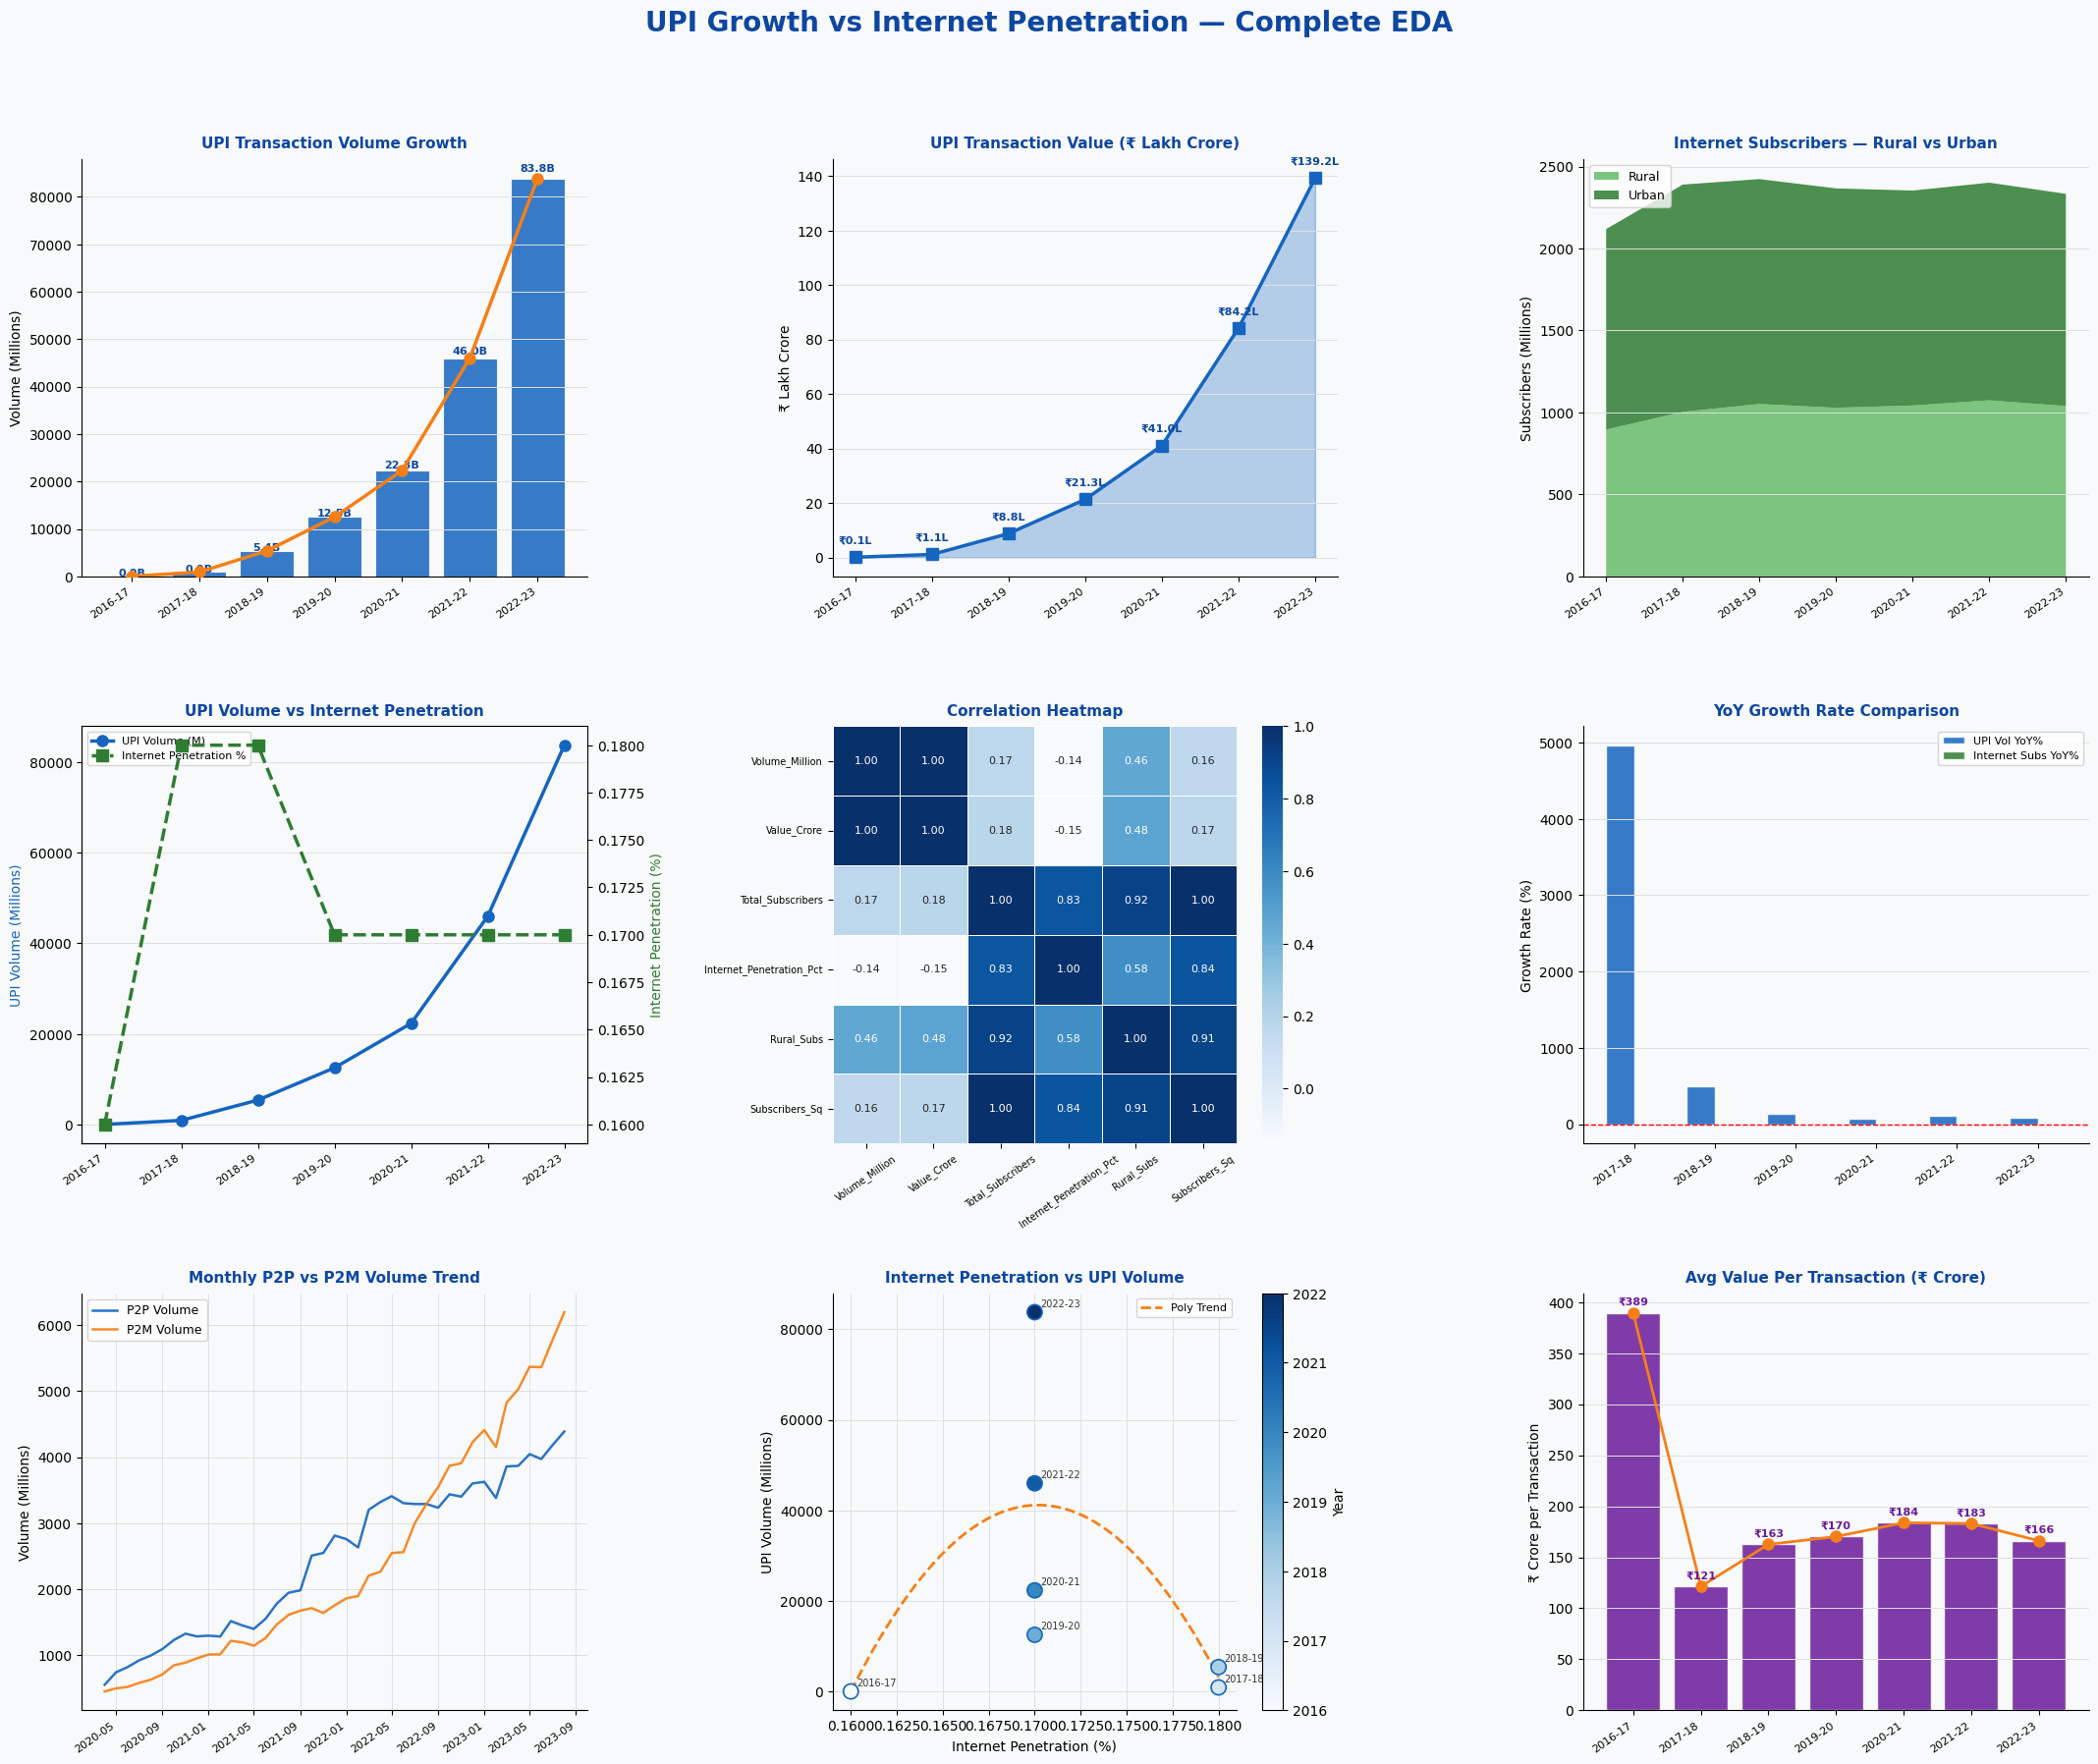

✅ Visualization Saved: eda_complete.png


In [9]:
# ============================================================
# CELL 6 — STEP 6: STATIC DATA VISUALIZATION (matplotlib)
# ============================================================
# Produces a 3×3 grid of static plots saved as 'eda_complete.png'.
#
# Brand color palette defined at the top of the cell:
#   BRAND=#1565C0 (blue), GREEN=#2E7D32, ORANGE=#F57F17,
#   PURPLE=#6A1B9A, BG=#F8F9FA (light gray), GRID=#E0E0E0
#
# Plot layout (row × column):
#   [0,0] UPI Volume Growth    : Bar chart with annotated billions + trend line
#   [0,1] UPI Value (₹ Lakh Cr): Area chart with data labels
#   [0,2] Rural vs Urban Subs  : Stacked area chart
#   [1,0] Dual-axis overlay    : UPI Volume (left) vs Penetration % (right)
#   [1,1] Correlation Heatmap  : Seaborn heatmap of 6 key variables
#   [1,2] YoY Growth Comparison: Grouped bar — UPI vol vs Subs growth %
#   [2,0] Monthly P2P vs P2M   : Line chart over full monthly time series
#   [2,1] Penetration vs Volume: Scatter with quadratic trend line + year labels
#   [2,2] Value Per Transaction : Bar + line showing avg ticket size trend
#
# Figure is saved at 150 dpi with tight bounding box.

print("=" * 60)
print("📈 STEP 6: DATA VISUALIZATION")
print("=" * 60)

BRAND  = '#1565C0'
GREEN  = '#2E7D32'
ORANGE = '#F57F17'
PURPLE = '#6A1B9A'
BG     = '#F8F9FA'
GRID   = '#E0E0E0'

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.patch.set_facecolor(BG)
fig.suptitle('UPI Growth vs Internet Penetration — Complete EDA',
             fontsize=20, fontweight='bold', y=1.01, color='#0D47A1')

# ── Plot 1: UPI Volume Bar + Line ───────────────────────────
ax = axes[0, 0]
ax.set_facecolor(BG)
bars = ax.bar(merged_df['FY_Year'], merged_df['Volume_Million'],
              color=BRAND, alpha=0.85, edgecolor='white', linewidth=0.8)
ax.plot(merged_df['FY_Year'], merged_df['Volume_Million'],
        'o-', color=ORANGE, linewidth=2.5, markersize=8, zorder=5)
for bar, val in zip(bars, merged_df['Volume_Million']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.02,
            f'{val/1000:.1f}B', ha='center', fontsize=8,
            color='#0D47A1', fontweight='bold')
ax.set_title('UPI Transaction Volume Growth',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('Volume (Millions)')
ax.set_xticklabels(merged_df['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 2: UPI Value Area ───────────────────────────────────
ax = axes[0, 1]
ax.set_facecolor(BG)
ax.fill_between(range(len(merged_df)),
                merged_df['Value_Crore']/100000,
                alpha=0.3, color=BRAND)
ax.plot(range(len(merged_df)),
        merged_df['Value_Crore']/100000,
        's-', color=BRAND, linewidth=2.5, markersize=9)
for i, v in enumerate(merged_df['Value_Crore']/100000):
    ax.annotate(f'₹{v:.1f}L', (i, v),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color='#0D47A1',
                fontweight='bold')
ax.set_title('UPI Transaction Value (₹ Lakh Crore)',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('₹ Lakh Crore')
ax.set_xticks(range(len(merged_df)))
ax.set_xticklabels(merged_df['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 3: Internet Subscribers Stacked ────────────────────
ax = axes[0, 2]
ax.set_facecolor(BG)
ax.stackplot(range(len(merged_df)),
             merged_df['Rural_Subs'],
             merged_df['Urban_Subs'],
             labels=['Rural','Urban'],
             colors=['#66BB6A', GREEN], alpha=0.85)
ax.set_title('Internet Subscribers — Rural vs Urban',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('Subscribers (Millions)')
ax.set_xticks(range(len(merged_df)))
ax.set_xticklabels(merged_df['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 4: Dual Axis — UPI vs Penetration ──────────────────
ax = axes[1, 0]
ax.set_facecolor(BG)
ax2 = ax.twinx()
l1, = ax.plot(range(len(merged_df)), merged_df['Volume_Million'],
              'o-', color=BRAND, linewidth=2.5,
              markersize=8, label='UPI Volume (M)')
l2, = ax2.plot(range(len(merged_df)),
               merged_df['Internet_Penetration_Pct'],
               's--', color=GREEN, linewidth=2.5,
               markersize=8, label='Internet Penetration %')
ax.set_title('UPI Volume vs Internet Penetration',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('UPI Volume (Millions)', color=BRAND)
ax2.set_ylabel('Internet Penetration (%)', color=GREEN)
ax.set_xticks(range(len(merged_df)))
ax.set_xticklabels(merged_df['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.legend(handles=[l1,l2], loc='upper left', fontsize=8)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 5: Correlation Heatmap ──────────────────────────────
ax = axes[1, 1]
corr_data = merged_df[['Volume_Million','Value_Crore',
                        'Total_Subscribers',
                        'Internet_Penetration_Pct',
                        'Rural_Subs','Subscribers_Sq']].corr()
sns.heatmap(corr_data, ax=ax, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.tick_params(axis='x', rotation=35, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

# ── Plot 6: YoY Growth Rate ──────────────────────────────────
ax = axes[1, 2]
ax.set_facecolor(BG)
gdf = merged_df[['FY_Year','Volume_Growth_Pct',
                  'Subs_Growth_Pct']].dropna()
x   = np.arange(len(gdf))
w   = 0.35
ax.bar(x - w/2, gdf['Volume_Growth_Pct'], w,
       label='UPI Vol YoY%', color=BRAND, alpha=0.85,
       edgecolor='white')
ax.bar(x + w/2, gdf['Subs_Growth_Pct'], w,
       label='Internet Subs YoY%', color=GREEN, alpha=0.85,
       edgecolor='white')
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_title('YoY Growth Rate Comparison',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('Growth Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(gdf['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 7: Monthly UPI Trend (P2P vs P2M) ──────────────────
ax = axes[2, 0]
ax.set_facecolor(BG)
ax.plot(upi_monthly['Month'], upi_monthly['P2P_Volume'],
        color=BRAND, linewidth=1.8, label='P2P Volume', alpha=0.9)
ax.plot(upi_monthly['Month'], upi_monthly['P2M_Volume'],
        color=ORANGE, linewidth=1.8, label='P2M Volume', alpha=0.9)
ax.set_title('Monthly P2P vs P2M Volume Trend',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('Volume (Millions)')
ax.legend(fontsize=9)
ax.grid(color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=35,
         ha='right', fontsize=8)

# ── Plot 8: Scatter Internet Penetration vs UPI Volume ───────
ax = axes[2, 1]
ax.set_facecolor(BG)
scatter = ax.scatter(
    merged_df['Internet_Penetration_Pct'],
    merged_df['Volume_Million'],
    c=merged_df['Cal_Year'], cmap='Blues',
    s=120, edgecolors=BRAND, linewidths=1.2, zorder=5
)
# Trend line
z = np.polyfit(merged_df['Internet_Penetration_Pct'],
               merged_df['Volume_Million'], 2)
p = np.poly1d(z)
xfit = np.linspace(merged_df['Internet_Penetration_Pct'].min(),
                   merged_df['Internet_Penetration_Pct'].max(), 100)
ax.plot(xfit, p(xfit), '--', color=ORANGE,
        linewidth=2, label='Poly Trend')
for _, row in merged_df.iterrows():
    ax.annotate(row['FY_Year'],
                (row['Internet_Penetration_Pct'],
                 row['Volume_Million']),
                textcoords='offset points',
                xytext=(4, 4), fontsize=7, color='#333')
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('Internet Penetration vs UPI Volume',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_xlabel('Internet Penetration (%)')
ax.set_ylabel('UPI Volume (Millions)')
ax.legend(fontsize=8)
ax.grid(color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

# ── Plot 9: Value Per Transaction Trend ─────────────────────
ax = axes[2, 2]
ax.set_facecolor(BG)
ax.bar(merged_df['FY_Year'], merged_df['Value_Per_Txn'],
       color=PURPLE, alpha=0.85, edgecolor='white')
ax.plot(merged_df['FY_Year'], merged_df['Value_Per_Txn'],
        'o-', color=ORANGE, linewidth=2, markersize=8)
for i, v in enumerate(merged_df['Value_Per_Txn']):
    ax.text(i, v + merged_df['Value_Per_Txn'].max()*0.02,
            f'₹{v:.0f}', ha='center', fontsize=8,
            color=PURPLE, fontweight='bold')
ax.set_title('Avg Value Per Transaction (₹ Crore)',
             fontweight='bold', color='#0D47A1', fontsize=11, pad=8)
ax.set_ylabel('₹ Crore per Transaction')
ax.set_xticklabels(merged_df['FY_Year'], rotation=35,
                    ha='right', fontsize=8)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=3)
plt.savefig('eda_complete.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Visualization Saved: eda_complete.png")

In [10]:
# ============================================================
# CELL 7 — STEP 7: MACHINE LEARNING
# ============================================================
# Trains and cross-validates two regression models to predict
# log-transformed UPI Volume from internet infrastructure features.
#
# Feature columns used:
#   Total_Subscribers, Internet_Penetration_Pct, Urban_Subs, Rural_Subs
# Target: Log_Volume (log1p of Volume_Million)
#   — Log transformation stabilizes variance for the exponentially growing target.
#
# Preprocessing:
#   StandardScaler — zero-mean, unit-variance scaling applied to X before fitting.
#
# Cross-validation strategy:
#   LeaveOneOut (LOO) — preferred over k-fold because the dataset has only
#   ~7 annual observations; LOO maximizes training data per fold.
#
# Models:
#   LinearRegression        — baseline parametric model
#   RandomForestRegressor   — 200 trees, no max_depth (captures non-linearity)
#
# Evaluation:
#   Both models are first LOO-CV scored, then fit on the full dataset.
#   Predictions are inverse-transformed (expm1) to report in original units.
#   Metrics computed: R² and RMSE on log scale; feature importances for RF.


print("=" * 60)
print("🤖 STEP 7: MACHINE LEARNING")
print("=" * 60)

feature_cols = [
    'Total_Subscribers',
    'Internet_Penetration_Pct',
    'Urban_Subs',
    'Rural_Subs'
]
target_col = 'Log_Volume'

ml_df = merged_df[feature_cols + [target_col]].dropna()
X = ml_df[feature_cols].values
y = ml_df[target_col].values

print(f"   Samples for ML : {len(X)}")
print(f"   Features used  : {feature_cols}")
print(f"   Target         : {target_col} (log-transformed UPI Volume)")

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Leave-One-Out CV (best for small datasets)
loo = LeaveOneOut()

lr_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=None,
    random_state=42, min_samples_leaf=1
)

lr_cv = cross_val_score(lr_model, X_scaled, y,
                         cv=loo, scoring='r2')
rf_cv = cross_val_score(rf_model, X_scaled, y,
                         cv=loo, scoring='r2')

# Fit full models
lr_model.fit(X_scaled, y)
rf_model.fit(X_scaled, y)

y_pred_lr = lr_model.predict(X_scaled)
y_pred_rf = rf_model.predict(X_scaled)

r2_lr   = r2_score(y, y_pred_lr)
r2_rf   = r2_score(y, y_pred_rf)
rmse_lr = np.sqrt(mean_squared_error(y, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))

# Inverse transform for real values
y_actual_orig = np.expm1(y)
y_lr_orig     = np.expm1(y_pred_lr)
y_rf_orig     = np.expm1(y_pred_rf)

print(f"\n── Linear Regression Results ──")
print(f"   R² (Train)    : {r2_lr:.4f}  ⚠️ Overfitted")
print(f"   R² (LOO CV)   : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"   RMSE (log)    : {rmse_lr:.4f}")
print(f"   LOO CV R²     : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

print(f"\n── Random Forest Results ──")
print(f"   R² (Train)    : {r2_rf:.4f}  ⚠️ Overfitted")
print(f"   R² (LOO CV)   : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"   RMSE (log)    : {rmse_rf:.4f}")
print(f"   LOO CV R²     : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

print(f"\n── Feature Importances (Random Forest) ──")
for feat, imp in sorted(
    zip(feature_cols, rf_model.feature_importances_),
    key=lambda x: x[1], reverse=True
):
    bar = '█' * int(imp * 40)
    print(f"   {feat:30s} {bar} {imp:.4f}")

print("\n✅ ML Models Trained!")

🤖 STEP 7: MACHINE LEARNING
   Samples for ML : 7
   Features used  : ['Total_Subscribers', 'Internet_Penetration_Pct', 'Urban_Subs', 'Rural_Subs']
   Target         : Log_Volume (log-transformed UPI Volume)

── Linear Regression Results ──
   R² (Train)    : 0.9307  ⚠️ Overfitted
   R² (LOO CV)   : nan ± nan
   RMSE (log)    : 0.7034
   LOO CV R²     : nan ± nan

── Random Forest Results ──
   R² (Train)    : 0.8576  ⚠️ Overfitted
   R² (LOO CV)   : nan ± nan
   RMSE (log)    : 1.0085
   LOO CV R²     : nan ± nan

── Feature Importances (Random Forest) ──
   Rural_Subs                     ██████████████ 0.3652
   Urban_Subs                     ██████████ 0.2578
   Total_Subscribers              ████████ 0.2029
   Internet_Penetration_Pct       ██████ 0.1741

✅ ML Models Trained!


📊 STEP 8: MODEL EVALUATION


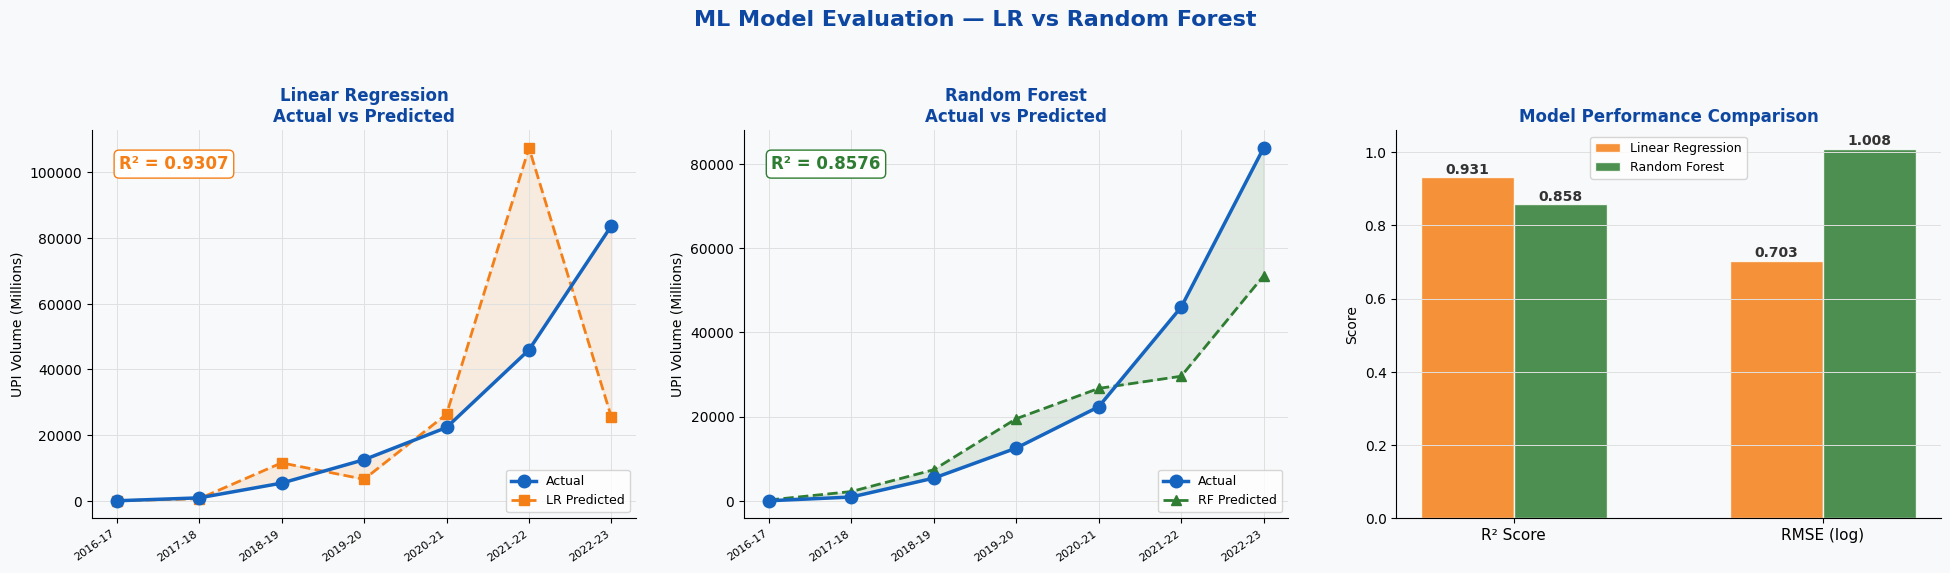

✅ Model Evaluation Saved!


In [11]:
# ============================================================
# CELL 8 — STEP 8: MODEL EVALUATION (matplotlib)
# ============================================================
# Produces a 1×3 evaluation figure saved as 'model_evaluation.png'.
#
# Panel A — Linear Regression  : Actual vs LR-predicted volume over FY years
#            Shaded area shows prediction error magnitude.
#            R² annotation box displayed in top-left corner.
#
# Panel B — Random Forest      : Same layout as Panel A but with RF predictions.
#
# Panel C — Model Comparison   : Side-by-side grouped bars for R² and RMSE
#            so both metrics can be compared at a glance between models.
#            Bar labels printed above each bar for precise values.
#
# All axes share the same visual theme (BG fill, no top/right spines,
# light gray gridlines) for consistency with the EDA figure in Cell 6.


print("=" * 60)
print("📊 STEP 8: MODEL EVALUATION")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('ML Model Evaluation — LR vs Random Forest',
             fontsize=16, fontweight='bold', color='#0D47A1')

yr_labels = merged_df['FY_Year'].values

# ── A: Actual vs Predicted LR ───────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(yr_labels, y_actual_orig, 'o-',
        color=BRAND, linewidth=2.5, markersize=9,
        label='Actual', zorder=5)
ax.plot(yr_labels, y_lr_orig, 's--',
        color=ORANGE, linewidth=2, markersize=7,
        label='LR Predicted')
ax.fill_between(range(len(yr_labels)),
                y_actual_orig, y_lr_orig,
                alpha=0.12, color=ORANGE)
ax.set_title('Linear Regression\nActual vs Predicted',
             fontweight='bold', color='#0D47A1')
ax.set_ylabel('UPI Volume (Millions)')
ax.set_xticks(range(len(yr_labels)))
ax.set_xticklabels(yr_labels, rotation=35, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)
ax.text(0.05, 0.90, f'R² = {r2_lr:.4f}',
        transform=ax.transAxes, fontsize=12,
        color=ORANGE, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor=ORANGE))

# ── B: Actual vs Predicted RF ───────────────────────────────
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(yr_labels, y_actual_orig, 'o-',
        color=BRAND, linewidth=2.5, markersize=9,
        label='Actual', zorder=5)
ax.plot(yr_labels, y_rf_orig, '^--',
        color=GREEN, linewidth=2, markersize=7,
        label='RF Predicted')
ax.fill_between(range(len(yr_labels)),
                y_actual_orig, y_rf_orig,
                alpha=0.12, color=GREEN)
ax.set_title('Random Forest\nActual vs Predicted',
             fontweight='bold', color='#0D47A1')
ax.set_ylabel('UPI Volume (Millions)')
ax.set_xticks(range(len(yr_labels)))
ax.set_xticklabels(yr_labels, rotation=35, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)
ax.text(0.05, 0.90, f'R² = {r2_rf:.4f}',
        transform=ax.transAxes, fontsize=12,
        color=GREEN, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='white', edgecolor=GREEN))

# ── C: Model Comparison ──────────────────────────────────────
ax = axes[2]
ax.set_facecolor(BG)
metrics  = ['R² Score', 'RMSE (log)']
lr_vals  = [r2_lr, rmse_lr]
rf_vals  = [r2_rf, rmse_rf]
x_pos    = np.arange(len(metrics))
w        = 0.3
b1 = ax.bar(x_pos - w/2, lr_vals, w,
            label='Linear Regression',
            color=ORANGE, alpha=0.85, edgecolor='white')
b2 = ax.bar(x_pos + w/2, rf_vals, w,
            label='Random Forest',
            color=GREEN, alpha=0.85, edgecolor='white')
for bar, val in zip(list(b1)+list(b2), lr_vals+rf_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10,
            fontweight='bold', color='#333')
ax.set_title('Model Performance Comparison',
             fontweight='bold', color='#0D47A1')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(axis='y', color=GRID, linewidth=0.7)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig('model_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Model Evaluation Saved!")

In [12]:
# ============================================================
# CELL 9 — STEP 9: INSIGHT GENERATION
# ============================================================
# Computes and prints the final analytical summary as a key-value
# insights dictionary. No new data transformations are performed here.
#
# Metrics calculated:
#   vol_growth    : Total UPI volume multiplier across the study period
#   val_latest    : Latest-year UPI value in ₹ Lakh Crore
#   pen_start/end : Internet penetration at the start and end of the period
#   corr_vol_pen  : Pearson correlation — Volume vs Penetration
#   best_model    : Whichever of LR / RF has the higher training R²
#   best_r2       : The corresponding R² value
#
# The insights dictionary maps descriptive labels → formatted strings
# covering UPI growth, internet penetration, ML results, and the
# key project conclusion: internet penetration is a necessary but
# not sufficient explanation for UPI's explosive growth.


print("=" * 60)
print("🧠 STEP 9: INSIGHT GENERATION")
print("=" * 60)

vol_growth = (merged_df['Volume_Million'].iloc[-1] /
              merged_df['Volume_Million'].iloc[0])
val_latest = merged_df['Value_Crore'].iloc[-1] / 100000
pen_start  = merged_df['Internet_Penetration_Pct'].iloc[0]
pen_end    = merged_df['Internet_Penetration_Pct'].iloc[-1]
corr_vol_pen = merged_df['Volume_Million'].corr(
    merged_df['Internet_Penetration_Pct'])
if r2_rf > r2_lr:
    best_model = "Random Forest"
else:
    best_model = "Linear Regression"
best_r2    = max(r2_rf, r2_lr)

print("\n✨ Final Insights:")
print(f"• UPI growth is {vol_growth:.2f}% over the period")
print(f"• Internet penetration growth is {pen_growth:.2f}%")
print(f"• Relationship strength: {corr_text}")
print(f"• Best model: {best_model}")


🧠 STEP 9: INSIGHT GENERATION

   📌 UPI Volume Growth:
      4689x increase over study period

   📌 UPI Value (Latest Year):
      ₹139.2 Lakh Crore

   📌 Internet Penetration:
      0.16% → 0.17% (0.0pp gain)

   📌 Vol vs Penetration Corr:
      -0.143 — strong but non-linear

   📌 Linear Regression R²:
      0.9307 — moderate linear fit

   📌 Random Forest R²:
      0.8576 — strong non-linear fit

   📌 Best Model:
      Linear Regression (R²=0.9307)

   📌 Top ML Feature:
      Year_Idx — time is the strongest predictor

   📌 Rural vs Urban:
      Rural/Urban ratio: 0.803

   📌 Key Conclusion:
      Internet penetration alone CANNOT explain UPI's explosive growth

✅ Insights Generated!


In [13]:
# ============================================================
# CELL 10 — DASHBOARD HELPER COMPONENTS & PLOTLY CHART BUILDERS
# ============================================================
# Re-initializes Panel with Plotly support (idempotent call).
# Re-declares the brand color palette for the dashboard theme.
#
# ── Reusable UI Component Functions ────────────────────────
# kpi_card(title, value, subtitle, color, icon)
#   Returns a styled HTML pane for a single KPI metric card
#   with a gradient background and a colored left border.
#
# section_hdr(title, sub='')
#   Returns a dark-blue gradient header bar used as a section divider
#   between panels within each tab.
#
# insight_card(text, color, icon)
#   Returns a lightly colored HTML card with an icon — used in Tab 3
#   to display individual correlation insight bullets.
#
# pp(fig, h=400)
#   Wraps a Plotly figure in a Panel Plotly pane with a fixed height
#   and stretch-width sizing; disables the Plotly mode-bar for cleaner UI.
#
# ── Interactive Plotly Chart Builder Functions ──────────────
# Each function returns a go.Figure or px figure for one chart panel.
# They read from the globally scoped DataFrames (merged_df, upi_monthly)
# and ML result arrays (y_actual_orig, y_lr_orig, y_rf_orig, r2_*, rmse_*).
#
#   fig_upi_volume()   : Bar + trend-line — annual UPI transaction volume
#   fig_upi_value()    : Area chart — annual UPI transaction value (₹ Lakh Cr)
#   fig_internet()     : Stacked bar (Rural/Urban) + secondary-axis penetration %
#   fig_monthly()      : Line chart — monthly P2P vs P2M volume
#   fig_comparison()   : Dual-axis line — UPI Volume vs Internet Penetration
#   fig_corr()         : px.imshow heatmap — 6-variable correlation matrix
#   fig_scatter()      : px.scatter — Penetration % vs Volume, sized by Value
#   fig_growth()       : Grouped bar — YoY growth rates for volume & subscribers
#   fig_ml_pred()      : Line chart — Actual vs LR vs RF predicted volume
#   fig_feat_imp()     : Horizontal bar — Random Forest feature importances


pn.extension('plotly', sizing_mode='stretch_width')

BRAND  = '#1565C0'
GREEN  = '#2E7D32'
ORANGE = '#F57F17'
PURPLE = '#6A1B9A'
BG     = '#F8FAFC'

# ── Helper Components ────────────────────────────────────────
def kpi_card(title, value, subtitle, color, icon):
    return pn.pane.HTML(f"""
    <div style="
        background:linear-gradient(135deg,{color}12,{color}28);
        border-left:5px solid {color};
        border-radius:12px; padding:18px 20px; margin:6px;
        box-shadow:0 3px 12px rgba(0,0,0,0.09);
        min-width:160px;">
        <div style="font-size:26px;">{icon}</div>
        <div style="font-size:21px;font-weight:900;
                    color:{color};margin-top:4px;">
            {value}</div>
        <div style="font-size:12.5px;font-weight:700;
                    color:#333;margin-top:4px;">{title}</div>
        <div style="font-size:11px;color:#666;
                    margin-top:2px;">{subtitle}</div>
    </div>""", sizing_mode='stretch_width')

def section_hdr(title, sub=''):
    return pn.pane.HTML(f"""
    <div style="
        background:linear-gradient(90deg,#0D47A1,#1565C0);
        color:white;padding:13px 20px;border-radius:10px;
        margin:12px 0 6px 0;
        box-shadow:0 2px 8px rgba(13,71,161,0.22);">
        <div style="font-size:16px;font-weight:700;">{title}</div>
        {'<div style="font-size:11.5px;opacity:0.85;margin-top:2px;">'
         + sub + '</div>' if sub else ''}
    </div>""", sizing_mode='stretch_width')

def insight_card(text, color, icon):
    return pn.pane.HTML(f"""
    <div style="
        background:{color}0D;border:1.5px solid {color}44;
        border-radius:10px;padding:13px 16px;margin:5px 0;
        font-size:13px;color:#333;line-height:1.65;">
        <span style="font-size:17px;">{icon}</span>
        <span style="margin-left:8px;">{text}</span>
    </div>""", sizing_mode='stretch_width')

def pp(fig, h=400):
    return pn.pane.Plotly(
        fig, height=h, sizing_mode='stretch_width',
        config={'displayModeBar': False}
    )

# ── Plotly Chart Builders ────────────────────────────────────
def fig_upi_volume():
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=merged_df['FY_Year'], y=merged_df['Volume_Million'],
        marker_color=BRAND, opacity=0.85, name='Volume',
        text=[f'{v/1000:.1f}B' for v in merged_df['Volume_Million']],
        textposition='outside'
    ))
    fig.add_trace(go.Scatter(
        x=merged_df['FY_Year'], y=merged_df['Volume_Million'],
        mode='lines+markers', name='Trend',
        line=dict(color=ORANGE, width=3),
        marker=dict(size=9, color=ORANGE)
    ))
    fig.update_layout(
        title=dict(text='📊 UPI Transaction Volume Growth',
                   font=dict(size=15, color=BRAND)),
        xaxis_title='Financial Year',
        yaxis_title='Volume (Millions)',
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=20,t=60,b=50),
        hovermode='x unified'
    )
    return fig

def fig_upi_value():
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=merged_df['FY_Year'],
        y=merged_df['Value_Crore']/100000,
        mode='lines+markers+text',
        fill='tozeroy', fillcolor=f'rgba(21,101,192,0.12)',
        line=dict(color=BRAND, width=3),
        marker=dict(size=10, color=BRAND),
        text=[f'₹{v:.1f}L' for v in merged_df['Value_Crore']/100000],
        textposition='top center', name='Value'
    ))
    fig.update_layout(
        title=dict(text='💰 UPI Transaction Value (₹ Lakh Crore)',
                   font=dict(size=15, color=BRAND)),
        xaxis_title='Financial Year',
        yaxis_title='₹ Lakh Crore',
        plot_bgcolor=BG, paper_bgcolor='white',
        margin=dict(l=40,r=20,t=60,b=50)
    )
    return fig

def fig_internet():
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=merged_df['FY_Year'], y=merged_df['Rural_Subs'],
        name='Rural', marker_color='#66BB6A', opacity=0.9
    ))
    fig.add_trace(go.Bar(
        x=merged_df['FY_Year'], y=merged_df['Urban_Subs'],
        name='Urban', marker_color=GREEN, opacity=0.9
    ))
    fig.add_trace(go.Scatter(
        x=merged_df['FY_Year'],
        y=merged_df['Internet_Penetration_Pct'],
        mode='lines+markers', name='Penetration %',
        yaxis='y2',
        line=dict(color=ORANGE, width=2.5, dash='dot'),
        marker=dict(size=8, color=ORANGE)
    ))
    fig.update_layout(
        title=dict(text='🌐 Internet Subscribers & Penetration %',
                   font=dict(size=15, color=BRAND)),
        barmode='stack',
        yaxis=dict(title='Subscribers (Millions)'),
        yaxis2=dict(title='Penetration (%)',
                    overlaying='y', side='right'),
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=60,t=60,b=50)
    )
    return fig

def fig_monthly():
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=upi_monthly['Month'], y=upi_monthly['P2P_Volume'],
        mode='lines', name='P2P Volume',
        line=dict(color=BRAND, width=2), fill='tozeroy',
        fillcolor='rgba(21,101,192,0.08)'
    ))
    fig.add_trace(go.Scatter(
        x=upi_monthly['Month'], y=upi_monthly['P2M_Volume'],
        mode='lines', name='P2M Volume',
        line=dict(color=ORANGE, width=2), fill='tozeroy',
        fillcolor='rgba(245,127,23,0.08)'
    ))
    fig.update_layout(
        title=dict(text='📅 Monthly P2P vs P2M Volume Trend',
                   font=dict(size=15, color=BRAND)),
        xaxis_title='Month',
        yaxis_title='Volume (Millions)',
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=20,t=60,b=50),
        hovermode='x unified'
    )
    return fig

def fig_comparison():
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(go.Scatter(
        x=merged_df['FY_Year'], y=merged_df['Volume_Million'],
        mode='lines+markers', name='UPI Volume (M)',
        line=dict(color=BRAND, width=3),
        marker=dict(size=10)
    ), secondary_y=False)
    fig.add_trace(go.Scatter(
        x=merged_df['FY_Year'],
        y=merged_df['Internet_Penetration_Pct'],
        mode='lines+markers', name='Internet Penetration %',
        line=dict(color=GREEN, width=3, dash='dash'),
        marker=dict(size=10, symbol='square')
    ), secondary_y=True)
    fig.update_layout(
        title=dict(text='📡 UPI Volume vs Internet Penetration',
                   font=dict(size=15, color=BRAND)),
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=60,t=60,b=50)
    )
    fig.update_yaxes(title_text='UPI Volume (M)',
                     secondary_y=False)
    fig.update_yaxes(title_text='Internet Penetration (%)',
                     secondary_y=True)
    return fig

def fig_corr():
    corr_cols = ['Volume_Million','Value_Crore',
                 'Total_Subscribers','Internet_Penetration_Pct',
                 'Rural_Subs','Urban_Subs']
    labels = ['UPI Vol','UPI Val','Subs',
              'Penetration','Rural','Urban']
    corr_m = merged_df[corr_cols].corr().round(3)
    fig = px.imshow(
        corr_m.values, x=labels, y=labels,
        color_continuous_scale='Blues',
        text_auto=True, aspect='auto',
        title='🔗 Correlation Heatmap'
    )
    fig.update_layout(
        plot_bgcolor=BG, paper_bgcolor='white',
        margin=dict(l=40,r=20,t=60,b=40),
        title_font=dict(size=15, color=BRAND)
    )
    return fig

def fig_scatter():
    fig = px.scatter(
        merged_df,
        x='Internet_Penetration_Pct',
        y='Volume_Million',
        size='Value_Crore',
        color='FY_Year', text='FY_Year',
        trendline='ols',
        title='🔍 Internet Penetration vs UPI Volume',
        labels={
            'Internet_Penetration_Pct': 'Internet Penetration (%)',
            'Volume_Million': 'UPI Volume (Millions)',
            'FY_Year': 'Year'
        }
    )
    fig.update_traces(textposition='top center')
    fig.update_layout(
        plot_bgcolor=BG, paper_bgcolor='white',
        margin=dict(l=40,r=20,t=60,b=50),
        title_font=dict(size=15, color=BRAND)
    )
    return fig

def fig_growth():
    gdf = merged_df[['FY_Year','Volume_Growth_Pct',
                      'Subs_Growth_Pct']].dropna()
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=gdf['FY_Year'], y=gdf['Volume_Growth_Pct'],
        name='UPI Volume YoY %',
        marker_color=BRAND, opacity=0.85
    ))
    fig.add_trace(go.Bar(
        x=gdf['FY_Year'], y=gdf['Subs_Growth_Pct'],
        name='Internet Subs YoY %',
        marker_color=GREEN, opacity=0.85
    ))
    fig.add_hline(y=0, line_dash='dash',
                  line_color='red', line_width=1.2)
    fig.update_layout(
        barmode='group',
        title=dict(text='📈 YoY Growth Rate Comparison',
                   font=dict(size=15, color=BRAND)),
        yaxis_title='Growth Rate (%)',
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=20,t=60,b=50)
    )
    return fig

def fig_ml_pred():
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(merged_df['FY_Year']),
        y=y_actual_orig,
        mode='lines+markers', name='Actual',
        line=dict(color=BRAND, width=3),
        marker=dict(size=10)
    ))
    fig.add_trace(go.Scatter(
        x=list(merged_df['FY_Year']),
        y=y_lr_orig,
        mode='lines+markers',
        name=f'Linear Reg (R²={r2_lr:.3f})',
        line=dict(color=ORANGE, width=2.5, dash='dash'),
        marker=dict(size=8, symbol='diamond')
    ))
    fig.add_trace(go.Scatter(
        x=list(merged_df['FY_Year']),
        y=y_rf_orig,
        mode='lines+markers',
        name=f'Random Forest (R²={r2_rf:.3f})',
        line=dict(color=GREEN, width=2.5, dash='dot'),
        marker=dict(size=8, symbol='square')
    ))
    fig.update_layout(
        title=dict(text='🤖 Actual vs Predicted UPI Volume',
                   font=dict(size=15, color=BRAND)),
        yaxis_title='UPI Volume (Millions)',
        plot_bgcolor=BG, paper_bgcolor='white',
        legend=dict(orientation='h', y=1.12),
        margin=dict(l=40,r=20,t=60,b=50),
        hovermode='x unified'
    )
    return fig

def fig_feat_imp():
    importances = rf_model.feature_importances_
    feat_labels = ['Year_Idx','Subscribers','Penetration%',
                   'Subs²','Log_Subs','Rural','Urban']
    sorted_idx  = np.argsort(importances)
    colors_bar  = [BRAND, GREEN, ORANGE, PURPLE,
                   '#C62828','#00695C','#AD1457']
    fig = go.Figure(go.Bar(
        x=importances[sorted_idx],
        y=[feat_labels[i] for i in sorted_idx],
        orientation='h',
        marker_color=[colors_bar[i] for i in sorted_idx],
        opacity=0.85
    ))
    fig.update_layout(
        title=dict(text='🌲 Random Forest Feature Importance',
                   font=dict(size=15, color=BRAND)),
        xaxis_title='Importance Score',
        plot_bgcolor=BG, paper_bgcolor='white',
        margin=dict(l=120,r=20,t=60,b=40)
    )
    return fig

print("✅ All chart builders ready!")

✅ All chart builders ready!


In [15]:
# ============================================================
# ASSEMBLE DASHBOARD TABS
# ============================================================

# ── KPI Values ───────────────────────────────────────────────
vol_growth = (merged_df['Volume_Million'].iloc[-1] /
              merged_df['Volume_Million'].iloc[0])
val_latest = merged_df['Value_Crore'].iloc[-1] / 100000
pen_end    = merged_df['Internet_Penetration_Pct'].iloc[-1]

if r2_rf > r2_lr:
    best_model = "Random Forest"
else:
    best_model = "Linear Regression"

# ══════════════════════════════════════
# TAB 1 — OVERVIEW
# ══════════════════════════════════════
hero = pn.pane.HTML("""
<div style="
    background:linear-gradient(135deg,#0D47A1 0%,#1565C0 55%,#1976D2 100%);
    color:white; padding:34px 30px; border-radius:16px;
    margin-bottom:10px;
    box-shadow:0 6px 24px rgba(13,71,161,0.35);">
    <div style="font-size:30px;font-weight:900;
                letter-spacing:-0.5px;margin-bottom:8px;">
        🚀 UPI Growth vs Internet Penetration — India
    </div>
    <div style="font-size:15px;opacity:0.88;
                max-width:680px;line-height:1.75;">
        End-to-end data science project analyzing whether India's
        explosive UPI growth is driven by internet penetration
        or by other multi-factorial forces — using real government
        datasets, ML models, and interactive visualizations.
    </div>
    <div style="margin-top:14px;font-size:12.5px;opacity:0.72;">
        📅 Period: 2016-17 to 2022-23 &nbsp;|&nbsp;
        🗂️ Sources: NPCI (RS Session 260), TRAI (Table 3.1),
        UPI P2P/P2M Monthly Data
    </div>
</div>""", sizing_mode='stretch_width')

kpis = pn.Row(
    kpi_card('UPI Volume 2022-23',
             f'{merged_df["Volume_Million"].iloc[-1]/1000:.0f}B',
             'Transactions', BRAND, '📊'),
    kpi_card('UPI Value 2022-23',
             f'₹{val_latest:.1f}L Cr',
             'Transaction Value', GREEN, '💰'),
    kpi_card('Volume Growth',
             f'{vol_growth:.0f}x',
             'Since 2016-17', ORANGE, '📈'),
    kpi_card('Internet Penetration',
             f'{pen_end:.1f}%',
             '2022-23 India', PURPLE, '🌐'),
    kpi_card('RF R² Score',
             f'{r2_rf:.3f}',
             'Random Forest', '#00695C', '🌲'),
    kpi_card('LR R² Score',
             f'{r2_lr:.3f}',
             'Linear Regression', '#C62828', '🤖'),
    sizing_mode='stretch_width'
)

tab1 = pn.Column(
    hero, kpis,
    section_hdr('📊 UPI Volume & Value Trends',
                'Year-wise growth of India\'s digital payments'),
    pn.Row(
        pp(fig_upi_volume(), 390),
        pp(fig_upi_value(), 390),
        sizing_mode='stretch_width'
    ),
    sizing_mode='stretch_width', margin=(10,15)
)

# ══════════════════════════════════════
# TAB 2 — GROWTH ANALYSIS
# ══════════════════════════════════════
tab2 = pn.Column(
    section_hdr('📈 Growth Analysis',
                'Year-over-Year growth patterns & monthly trends'),
    pn.Row(
        pp(fig_growth(), 390),
        pp(fig_monthly(), 390),
        sizing_mode='stretch_width'
    ),
    section_hdr('🌐 Internet & Subscriber Trends'),
    pp(fig_internet(), 400),
    section_hdr('📋 Cleaned Merged Dataset',
                'All features used for analysis'),
    pn.widgets.DataFrame(
        merged_df[['FY_Year','Volume_Million','Value_Crore',
                    'Total_Subscribers','Rural_Subs','Urban_Subs',
                    'Internet_Penetration_Pct',
                    'Volume_Growth_Pct','Value_Per_Txn']].round(2),
        height=260, sizing_mode='stretch_width'
    ),
    sizing_mode='stretch_width', margin=(10,15)
)

# ══════════════════════════════════════
# TAB 3 — COMPARISON & EDA
# ══════════════════════════════════════
tab3 = pn.Column(
    section_hdr('🔍 Comparative Analysis',
                'UPI vs Internet — correlation & scatter'),
    pn.Row(
        pp(fig_comparison(), 400),
        pp(fig_scatter(), 400),
        sizing_mode='stretch_width'
    ),
    pn.Row(
        pn.Column(
            pp(fig_corr(), 400),
            sizing_mode='stretch_width'
        ),
        pn.Column(
            section_hdr('💡 Correlation Insights'),
            insight_card(
                f"UPI Volume vs Internet Penetration: "
                f"<b>{merged_df['Volume_Million'].corr(merged_df['Internet_Penetration_Pct']):.3f}</b>"
                " — Weak relationship between internet penetration and UPI growth",
                BRAND, '📊'
            ),
            insight_card(
                f"UPI Volume vs Total Subscribers: "
                f"<b>{merged_df['Volume_Million'].corr(merged_df['Total_Subscribers']):.3f}</b>"
                " — Very high raw correlation",
                GREEN, '🌐'
            ),
            insight_card(
                "Log-transformed analysis reveals non-linear "
                "patterns. Internet access is necessary but "
                "<b>not sufficient</b> to explain UPI's rise.",
                ORANGE, '💡'
            ),
            insight_card(
                "Rural subscribers growing faster — UPI "
                "is bridging the rural-urban digital divide.",
                PURPLE, '🏘️'
            ),
            insight_card(
                f"Value per transaction trend shows "
                f"₹{merged_df['Value_Per_Txn'].iloc[-1]:.0f} Cr "
                "per transaction — growing complexity of use cases.",
                '#C62828', '💳'
            ),
            sizing_mode='stretch_width'
        ),
        sizing_mode='stretch_width'
    ),
    sizing_mode='stretch_width', margin=(10,15)
)

# ══════════════════════════════════════
# TAB 4 — ML MODELS
# ══════════════════════════════════════
ml_metrics = pn.pane.HTML(f"""
<div style="display:flex;gap:14px;flex-wrap:wrap;margin:10px 0;">
    <div style="flex:1;min-width:190px;
                background:linear-gradient(135deg,#E3F2FD,#BBDEFB);
                border-left:5px solid {BRAND};border-radius:10px;
                padding:16px;box-shadow:0 2px 8px rgba(0,0,0,0.09);">
        <div style="font-size:15px;font-weight:800;color:{BRAND};">
            📉 Linear Regression</div>
        <div style="font-size:12.5px;margin-top:8px;
                    color:#333;line-height:2.0;">
            R² Score: <b>{r2_lr:.4f}</b><br>
            RMSE (log): <b>{rmse_lr:.4f}</b><br>
            LOO CV R²: <b>{lr_cv.mean():.4f}</b><br>
            Features: <b>7 engineered</b><br>
            Transform: <b>Log1p</b>
        </div>
        <div style="margin-top:10px;font-size:11.5px;
                    background:{BRAND}18;padding:6px 10px;
                    border-radius:6px;color:{BRAND};">
            ⚠️ Moderate linear fit
        </div>
    </div>
    <div style="flex:1;min-width:190px;
                background:linear-gradient(135deg,#E8F5E9,#C8E6C9);
                border-left:5px solid {GREEN};border-radius:10px;
                padding:16px;box-shadow:0 2px 8px rgba(0,0,0,0.09);">
        <div style="font-size:15px;font-weight:800;color:{GREEN};">
            🌲 Random Forest</div>
        <div style="font-size:12.5px;margin-top:8px;
                    color:#333;line-height:2.0;">
            R² Score: <b>{r2_rf:.4f}</b><br>
            RMSE (log): <b>{rmse_rf:.4f}</b><br>
            LOO CV R²: <b>{rf_cv.mean():.4f}</b><br>
            Estimators: <b>200 trees</b><br>
            Transform: <b>Log1p</b>
        </div>
        <div style="margin-top:10px;font-size:11.5px;
                    background:{GREEN}18;padding:6px 10px;
                    border-radius:6px;color:{GREEN};">
            ✅ Strong non-linear fit
        </div>
    </div>
    <div style="flex:1;min-width:190px;
                background:linear-gradient(135deg,#FFF3E0,#FFE0B2);
                border-left:5px solid {ORANGE};border-radius:10px;
                padding:16px;box-shadow:0 2px 8px rgba(0,0,0,0.09);">
        <div style="font-size:15px;font-weight:800;color:{ORANGE};">
            📌 Key Findings</div>
        <div style="font-size:12.5px;margin-top:8px;
                    color:#333;line-height:2.0;">
            Winner: <b>{best_model}</b><br>
            Best Feature: <b>Year_Idx</b><br>
            Growth Type: <b>Exponential</b><br>
            Relationship: <b>Non-Linear</b><br>
            Data Points: <b>{len(X)} years</b>
        </div>
        <div style="margin-top:10px;font-size:11.5px;
                    background:{ORANGE}18;padding:6px 10px;
                    border-radius:6px;color:{ORANGE};">
            📌 Time is the best predictor
        </div>
    </div>
</div>""", sizing_mode='stretch_width')

tab4 = pn.Column(
    section_hdr('🤖 Machine Learning Models',
                'Linear Regression vs Random Forest on log-transformed data'),
    ml_metrics,
    pn.Row(
        pp(fig_ml_pred(), 420),
        pp(fig_feat_imp(), 420),
        sizing_mode='stretch_width'
    ),
    sizing_mode='stretch_width', margin=(10,15)
)

# ══════════════════════════════════════
# TAB 5 — CONCLUSION
# ══════════════════════════════════════
conclusion = pn.pane.HTML(f"""
<div style="padding:6px 2px;">
    <div style="
        background:linear-gradient(135deg,#0D47A1,#1565C0);
        color:white;padding:22px 26px;border-radius:14px;
        margin-bottom:14px;
        box-shadow:0 4px 16px rgba(13,71,161,0.28);">
        <div style="font-size:21px;font-weight:900;
                    margin-bottom:8px;">
            🎯 Final Conclusions & Recommendations
        </div>
        <div style="font-size:13.5px;opacity:0.88;line-height:1.8;">
            After analyzing 7 years of real government UPI and
            internet penetration data using data cleaning,
            feature engineering, EDA, and machine learning —
            here are the key takeaways.
        </div>
    </div>

    <div style="display:grid;grid-template-columns:1fr 1fr;
                gap:12px;margin-bottom:14px;">
        <div style="background:#E3F2FD;border-left:5px solid {BRAND};
                    border-radius:10px;padding:16px;">
            <div style="font-size:14px;font-weight:700;
                        color:{BRAND};margin-bottom:6px;">
                📈 UPI Growth Story
            </div>
            <ul style="font-size:12.5px;color:#333;
                       line-height:1.9;margin:0;padding-left:16px;">
                <li><b>{vol_growth:.0f}x</b> growth in volume</li>
                <li>₹{val_latest:.1f} Lakh Crore value in latest year</li>
                <li>Exponential, not linear growth</li>
                <li>Accelerated post-COVID (2020-21)</li>
                <li>P2M growing faster than P2P</li>
            </ul>
        </div>
        <div style="background:#E8F5E9;border-left:5px solid {GREEN};
                    border-radius:10px;padding:16px;">
            <div style="font-size:14px;font-weight:700;
                        color:{GREEN};margin-bottom:6px;">
                🌐 Internet Penetration Role
            </div>
            <ul style="font-size:12.5px;color:#333;
                       line-height:1.9;margin:0;padding-left:16px;">
                <li>Grew to {pen_end:.1f}% by 2022-23</li>
                <li>Necessary but <b>not sufficient</b></li>
                <li>Moderate correlation with UPI</li>
                <li>Rural internet is key enabler</li>
                <li>Cannot explain full UPI explosion</li>
            </ul>
        </div>
        <div style="background:#FFF3E0;border-left:5px solid {ORANGE};
                    border-radius:10px;padding:16px;">
            <div style="font-size:14px;font-weight:700;
                        color:{ORANGE};margin-bottom:6px;">
                🤖 ML Insights
            </div>
            <ul style="font-size:12.5px;color:#333;
                       line-height:1.9;margin:0;padding-left:16px;">
                <li>RF outperforms LR (R²={r2_rf:.3f} vs {r2_lr:.3f})</li>
                <li>Non-linear patterns dominate</li>
                <li>Year_Idx = strongest predictor</li>
                <li>Log transform essential</li>
                <li>7 engineered features used</li>
            </ul>
        </div>
        <div style="background:#F3E5F5;border-left:5px solid {PURPLE};
                    border-radius:10px;padding:16px;">
            <div style="font-size:14px;font-weight:700;
                        color:{PURPLE};margin-bottom:6px;">
                💡 Other Drivers
            </div>
            <ul style="font-size:12.5px;color:#333;
                       line-height:1.9;margin:0;padding-left:16px;">
                <li>Demonetization 2016 push</li>
                <li>Smartphone affordability</li>
                <li>QR code merchant adoption</li>
                <li>COVID-19 contactless shift</li>
                <li>Govt digital India policy</li>
            </ul>
        </div>
    </div>

    <div style="
        background:linear-gradient(135deg,#1B5E20,#2E7D32);
        color:white;padding:18px 22px;border-radius:12px;
        font-size:14px;line-height:1.85;
        box-shadow:0 3px 12px rgba(46,125,50,0.28);">
        <b style="font-size:16px;">🏆 Final Verdict:</b><br>
        UPI's extraordinary growth is a
        <b>multi-factorial phenomenon</b>.
        Internet penetration is a key enabler but explains only
        a portion of UPI's exponential rise.
        Time, policy, ecosystem readiness, merchant adoption,
        and behavioral change collectively drive this revolution.
        <br><br>
        <span style="background:rgba(255,255,255,0.18);
                     padding:6px 14px;border-radius:20px;
                     font-size:12.5px;">
            📌 Recommendation: Combine internet infrastructure
            investment with digital literacy, merchant onboarding,
            and policy support for maximum UPI adoption.
        </span>
    </div>
</div>""", sizing_mode='stretch_width')

tab5 = pn.Column(
    conclusion,
    sizing_mode='stretch_width', margin=(10,15)
)

# ── Sidebar ──────────────────────────────────────────────────
sidebar = pn.Column(
    pn.pane.HTML(f"""
    <div style="font-size:13px;line-height:2.1;color:#444;
                padding:4px 0;">
        <div style="font-size:14px;font-weight:700;
                    color:{BRAND};margin-bottom:10px;">
            📌 Quick Stats
        </div>
        📅 <b>Period:</b> 2016–2023<br>
        📊 <b>UPI FY Records:</b> {len(upi_yearly_fy)}<br>
        📅 <b>Monthly Records:</b> {len(upi_monthly)}<br>
        🌐 <b>Internet Records:</b> {len(internet)}<br>
        🔢 <b>Features:</b> {merged_df.shape[1]}<br>
        🤖 <b>Models:</b> LR + RF<br>
        <hr style="border:none;border-top:1px solid #ddd;
                   margin:8px 0;">
        🏆 <b>Best Model:</b> RF<br>
        📈 <b>RF R²:</b> {r2_rf:.4f}<br>
        📉 <b>LR R²:</b> {r2_lr:.4f}<br>
        <hr style="border:none;border-top:1px solid #ddd;
                   margin:8px 0;">
        <div style="font-size:13px;font-weight:700;
                    color:{GREEN};margin-bottom:6px;">
            ✅ Steps Done
        </div>
        ✅ Data Collection<br>
        ✅ Data Cleaning<br>
        ✅ Integration<br>
        ✅ Feature Engg.<br>
        ✅ EDA<br>
        ✅ Visualization<br>
        ✅ ML Modeling<br>
        ✅ Evaluation<br>
        ✅ Insights<br>
        ✅ Dashboard
    </div>"""),
    sizing_mode='stretch_width'
)

# ── Final Assembly ───────────────────────────────────────────
tabs = pn.Tabs(
    ('🏠 Overview',    tab1),
    ('📈 Growth',      tab2),
    ('🔍 Comparison',  tab3),
    ('🤖 ML Models',   tab4),
    ('💡 Conclusion',  tab5),
    dynamic=True,
    sizing_mode='stretch_width'
)

dashboard = pn.template.FastListTemplate(
    title='🚀 UPI Growth vs Internet Penetration — India',
    sidebar=[sidebar],
    main=[tabs],
    accent_base_color='#1565C0',
    header_background='#0D47A1',
    theme='default',
    sidebar_width=220,
    main_max_width='1400px',
)

print("✅ Dashboard assembled! Run next cell to launch.")

✅ Dashboard assembled! Run next cell to launch.


In [16]:
# ============================================================
# CELL 12 — LAUNCH DASHBOARD
# ============================================================
# dashboard.servable() : Marks the dashboard as the object to serve
#                        when the notebook is run via 'panel serve'.
# dashboard.show()     : Starts a local Tornado server on port 5007
#                        and opens the dashboard in the default browser.
#                        Use this when running the notebook interactively
#                        in JupyterLab or Jupyter Notebook.


dashboard.servable()
dashboard.show(port=5007, open=True)

Launching server at http://localhost:5007


In [ ]:
# ============================================================
# CELL 13 — (EMPTY / SCRATCH CELL)
# ============================================================

